# Pré-Processamento dos dados de entrada (KAGGLE e ATM)
**Objetivo:** Limpeza, seleção de features e interpolação dos dados de entrada para as modelagens.

**Premissas:** 
- Variáveis atmosféricas foram retiradas de reanálises numéricas, logo não foram tratadas em relação a gaps, outliers, etc.
- Eixo temporal padrão -> UTC
- As variáveis foram salvas sem normalização. A etapa de normalização será feita mediante necessidade dos modelos.

- Dados de entrada e saída disponíveis em: data


## 1. Leitura dos dados entre 2013 e 2019

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Poluentes e Atmosfera da estação de referencia = estação 08 (Congonhas)

In [3]:
poluentes = pd.read_csv("../data/dados_pm25_estacao8_2013_2019.csv")
poluentes.head()

,time,id,MP10,TRS,O3,NO2,CO,MP2.5,SO2,BENZENO,TOLUENO
0,2013-05-09 00:00:00,8,69.0,NaN,NaN,NaN,1.0,26.0,9.0,NaN,NaN
1,2013-05-09 01:00:00,8,35.0,NaN,NaN,NaN,0.6,21.0,6.0,NaN,NaN
2,2013-05-09 02:00:00,8,34.0,NaN,NaN,NaN,0.6,20.0,6.0,NaN,NaN
3,2013-05-09 03:00:00,8,35.0,NaN,NaN,NaN,0.5,18.0,NaN,NaN,NaN
4,2013-05-09 04:00:00,8,47.0,NaN,NaN,NaN,NaN,20.0,2.0,NaN,NaN


In [4]:
atmosfera = pd.read_csv("../data/openmeteo_historico_2013_2019.csv")
atmosfera.head()

,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2012-12-31 22:00:00-02:00,22.651001,89.586006,0.0,3.976330
1,2012-12-31 23:00:00-02:00,22.201000,90.384930,0.0,6.489992
2,2013-01-01 00:00:00-02:00,21.801000,90.357220,0.0,8.404284
3,2013-01-01 01:00:00-02:00,21.451000,90.053210,0.0,8.759178
4,2013-01-01 02:00:00-02:00,21.351000,88.658140,0.0,8.654986


In [5]:
# Dados da CETESB: considerar que estão em horário local de SP -> transformar para UTC
poluentes["time"] = (
    pd.to_datetime(poluentes["time"])
    .dt.tz_localize("Etc/GMT+3")
    .dt.tz_convert("UTC")
)

# Fuso já vem no time -> transformar para UTC
atmosfera["time"] = (
    pd.to_datetime(atmosfera["time"], utc=True)
)

In [6]:
# confirmar mesmo eixo de tempo
print(poluentes["time"].dtype)
print(atmosfera["time"].dtype)

datetime64[ns, UTC]
datetime64[ns, UTC]


In [7]:
atmosfera["time"].diff().value_counts().head(10)

time
0 days 01:00:00    61343
Name: count, dtype: int64

In [8]:
poluentes["time"].diff().value_counts().head(10)

time
0 days 01:00:00    55007
Name: count, dtype: int64

In [9]:
# juntar os dados pelo horário - Mantendo as variáveis básicas (PM25, temperatura, umidade)
df = pd.merge(
    poluentes[["time", "MP2.5"]],
    atmosfera[["time", "temperature_2m", "relative_humidity_2m","precipitation","wind_speed_10m"]],
    on="time",
    how="inner"
)

df = df.set_index("time")

In [10]:
df.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2013-05-09 03:00:00+00:00,26.0,10.301001,91.648320,0.0,7.421590
2013-05-09 04:00:00+00:00,21.0,9.751000,92.548310,0.0,7.993298
2013-05-09 05:00:00+00:00,20.0,9.401000,92.528390,0.0,7.928178
2013-05-09 06:00:00+00:00,18.0,9.251000,92.519806,0.0,7.280550
2013-05-09 07:00:00+00:00,20.0,9.851000,91.310250,0.0,6.287130


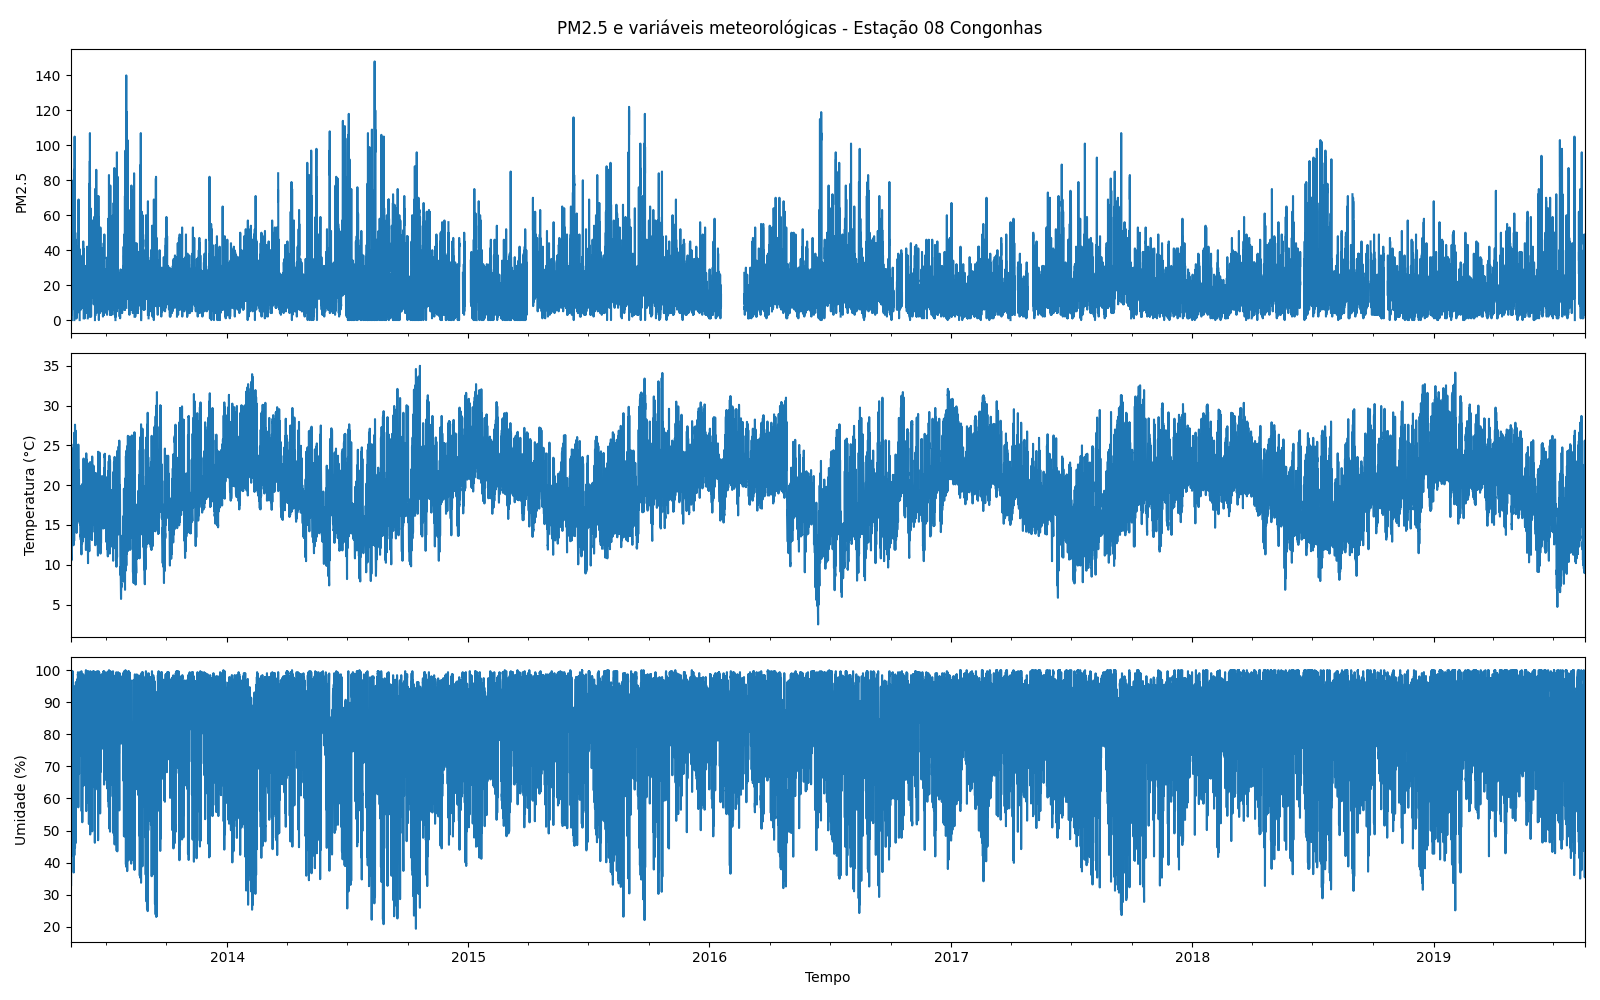

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

df["MP2.5"].plot(ax=axes[0])
axes[0].set_ylabel("PM2.5")

df["temperature_2m"].plot(ax=axes[1])
axes[1].set_ylabel("Temperatura (°C)")

df["relative_humidity_2m"].plot(ax=axes[2])
axes[2].set_ylabel("Umidade (%)")

axes[2].set_xlabel("Tempo")

fig.suptitle("PM2.5 e variáveis meteorológicas - Estação 08 Congonhas")
plt.tight_layout()
plt.show()

In [12]:
n_zeros = (df["MP2.5"] == 0).sum()
perc_zeros = 100 * n_zeros / len(df)
perc_zeros

0.7726148923792903

## 2. Analisando outliers na série de PM25

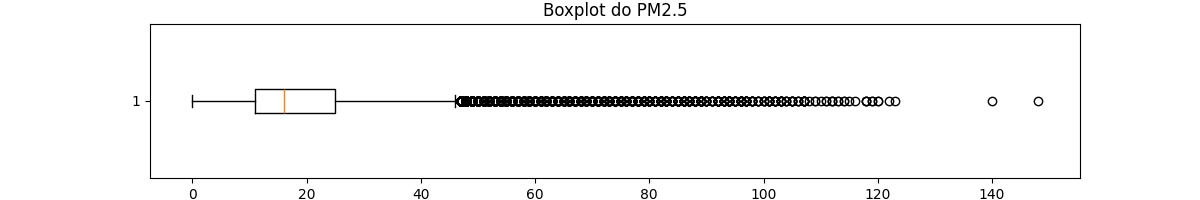

In [13]:
fig, ax = plt.subplots(figsize=(12,2))

ax.boxplot(
    df["MP2.5"].dropna(),
    vert=False
)

ax.set_title("Boxplot do PM2.5")
ax.set_xlabel("PM2.5")

plt.show()

## 3. Analisando gaps temporais de PM2.5

In [14]:
# série de PM2.5
serie = df["MP2.5"]

# identificar períodos com NaN
is_gap = serie.isna()

# grupos contínuos de NaN
grupos = (is_gap != is_gap.shift()).cumsum()

gaps = (
    df[is_gap]
    .groupby(grupos[is_gap])
    .apply(lambda x: pd.Series({
        "inicio": x.index.min(),
        "fim": x.index.max(),
        "duracao_h": len(x)
    }))
)

# gaps maiores que 12 horas
gaps_janela = gaps[gaps["duracao_h"] > 12]

gaps_janela

,inicio,fim,duracao_h
MP2.5,,,
68,2013-10-03 16:00:00+00:00,2013-10-04 13:00:00+00:00,22
88,2013-12-03 18:00:00+00:00,2013-12-04 16:00:00+00:00,23
150,2014-09-22 03:00:00+00:00,2014-09-22 22:00:00+00:00,20
164,2014-12-18 10:00:00+00:00,2014-12-23 15:00:00+00:00,126
168,2014-12-26 23:00:00+00:00,2015-01-04 15:00:00+00:00,209
174,2015-01-13 17:00:00+00:00,2015-01-16 14:00:00+00:00,70
180,2015-01-27 23:00:00+00:00,2015-01-28 12:00:00+00:00,14
182,2015-03-30 15:00:00+00:00,2015-04-08 17:00:00+00:00,219
184,2015-06-10 22:00:00+00:00,2015-06-11 16:00:00+00:00,19


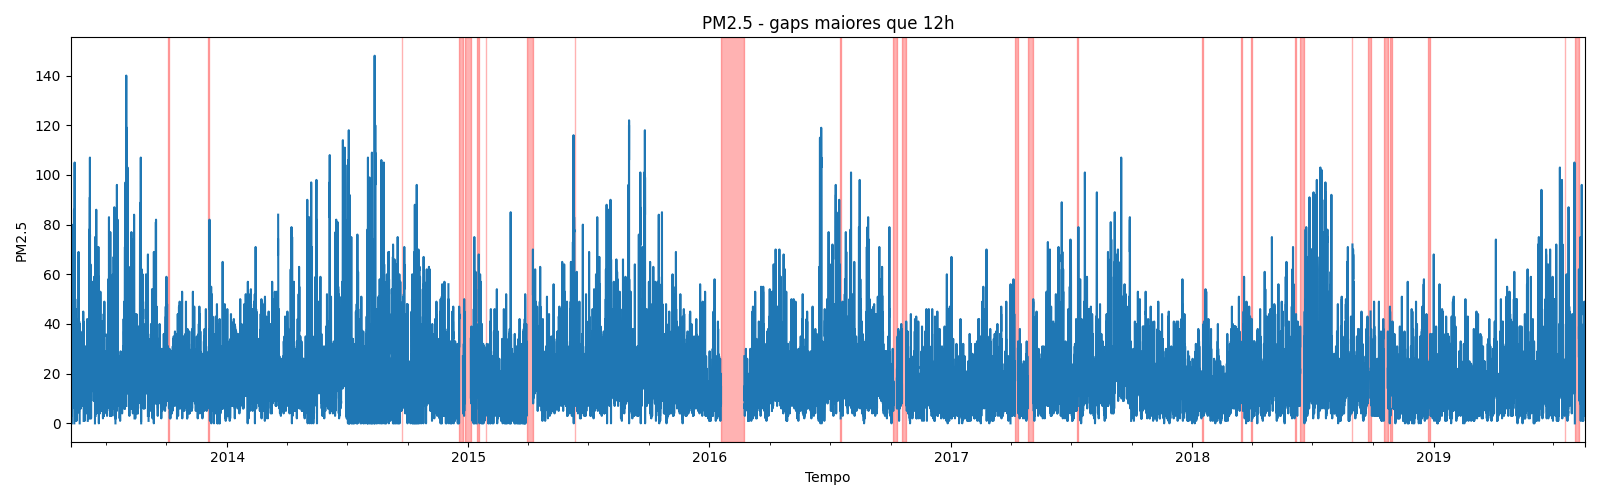

In [15]:
fig, ax = plt.subplots(figsize=(16, 5))

df["MP2.5"].plot(ax=ax)

for _, gap in gaps_janela.iterrows():
    ax.axvspan(
        gap["inicio"],
        gap["fim"],
        alpha=0.3,
        color="red"
    )

ax.set_title("PM2.5 - gaps maiores que 12h")
ax.set_ylabel("PM2.5")
ax.set_xlabel("Tempo")

plt.tight_layout()
plt.show()

In [16]:
# percentual de dados válidos
completude = df["MP2.5"].notna().mean() * 100

print(f"Completude = {completude:.1f}%")

Completude = 93.9%


In [17]:
gaps["duracao_h"].describe()

count    166.000000
mean      20.072289
std       75.303150
min        1.000000
25%        1.000000
50%        2.000000
75%        4.750000
max      845.000000
Name: duracao_h, dtype: float64

In [18]:
print("Gaps > 12h :", (gaps["duracao_h"] > 12).sum())
print("Gaps > 24h :", (gaps["duracao_h"] > 24).sum())
print("Gaps > 72h :", (gaps["duracao_h"] > 72).sum())
print("Gaps > 7 dias :", (gaps["duracao_h"] > 24*7).sum())

Gaps > 12h : 28
Gaps > 24h : 18
Gaps > 72h : 13
Gaps > 7 dias : 4


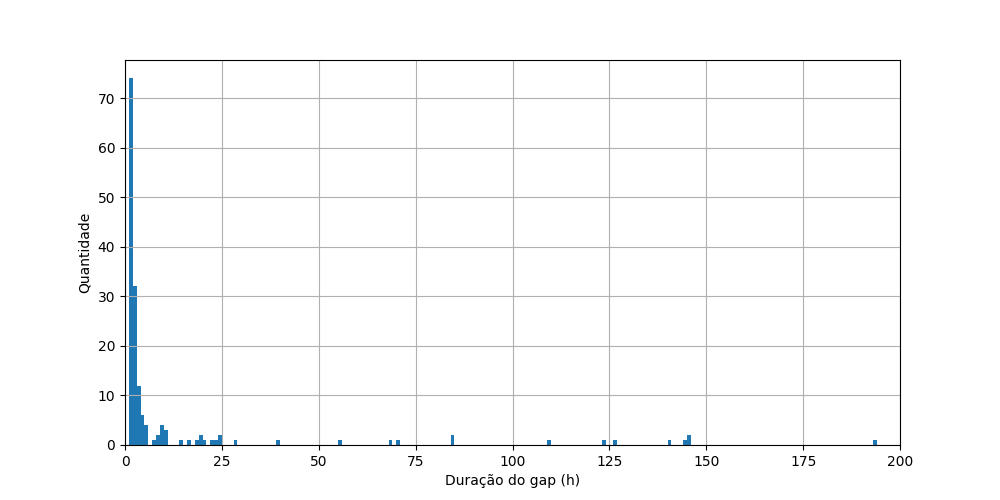

In [19]:
#duração dos gaps
plt.figure(figsize=(10,5))

gaps["duracao_h"].hist(
    bins=np.arange(1, 200, 1)
)

plt.xlabel("Duração do gap (h)")
plt.ylabel("Quantidade")
plt.xlim(0, 200)
plt.show()

## 4. Interpolando gaps Temporais 

### Estratégia 1 - Cortar série de março de 2016 para frente e deixar gaps com NaN

In [20]:
# O corte em 2016 foi para fugir do gap maior que existe no início de 2016.
# Além disso, os dados em 2015 parecem estranhos. Tem muitas medições perto do zero, fora do padrão de outros anos.
df_estrategia01 = df[df.index >= "2016-03-01"]

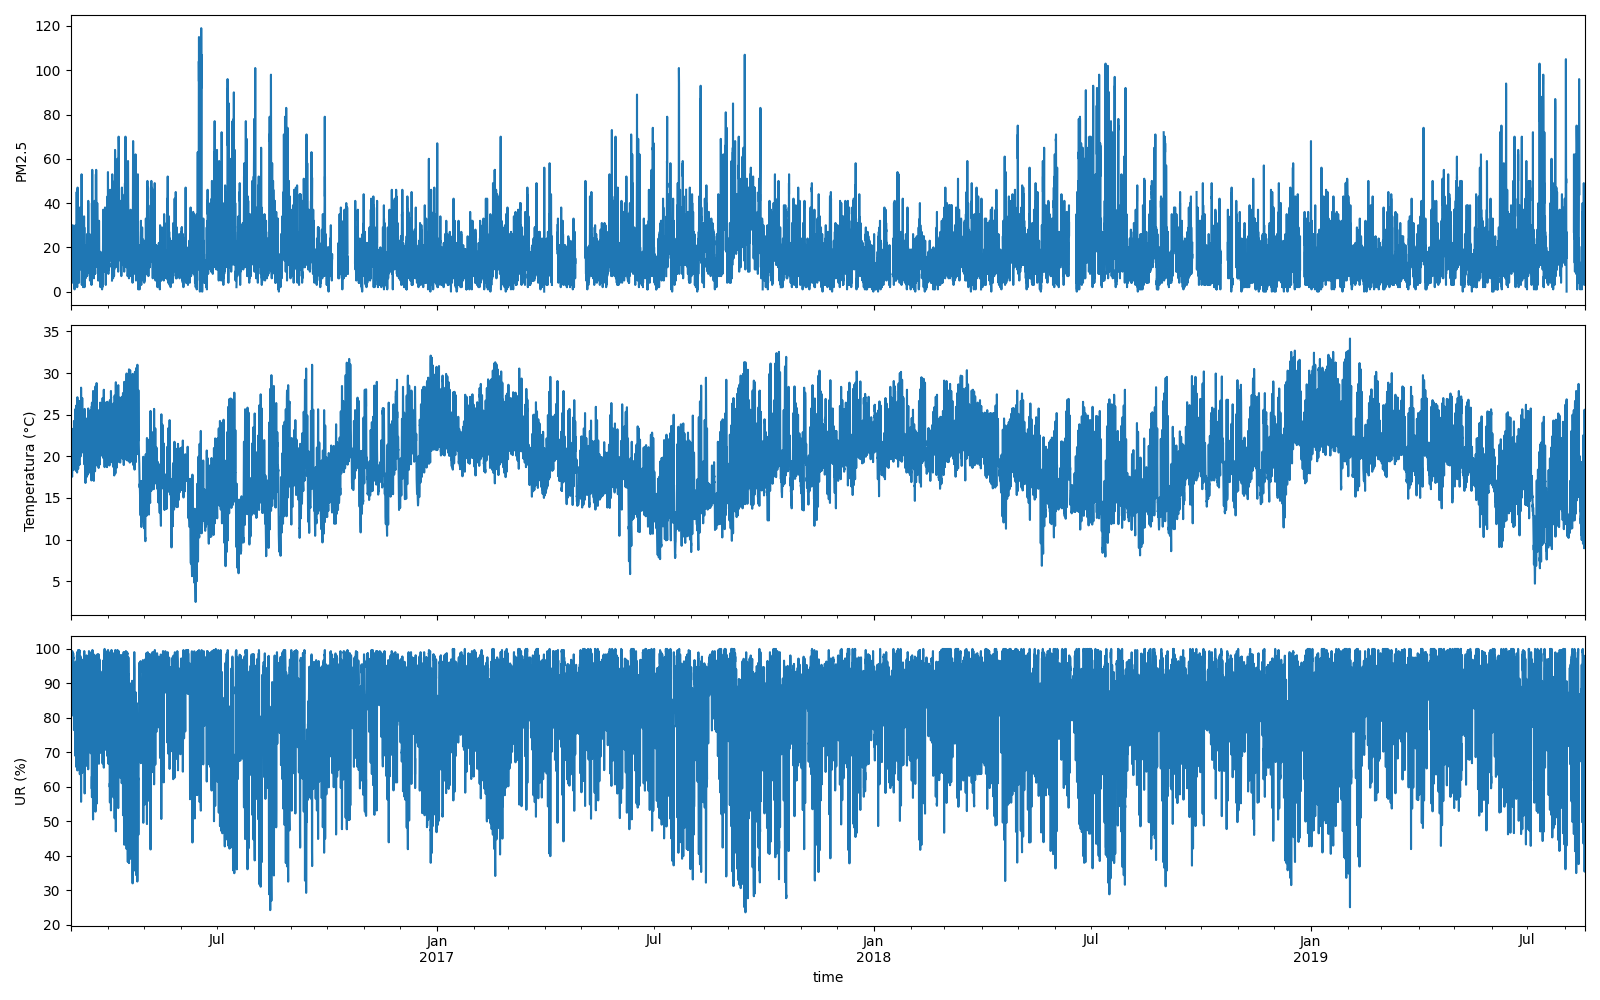

In [21]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

df_estrategia01["MP2.5"].plot(ax=axes[0])
axes[0].set_ylabel("PM2.5")

df_estrategia01["temperature_2m"].plot(ax=axes[1])
axes[1].set_ylabel("Temperatura (°C)")

df_estrategia01["relative_humidity_2m"].plot(ax=axes[2])
axes[2].set_ylabel("UR (%)")

plt.tight_layout()
plt.show()

In [23]:
#salvar
df_estrategia01.to_csv(
   "../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv",
   index=True
)

### Estratégia 2 - Cortar série de março de 2016 para frente e interpolar gaps <= 12h

In [24]:
df_estrategia02 = df.loc["2016-03-01":].copy()
limite_gap = 12

In [25]:
# somente interpolar para janelas de até 12h.
is_nan = df_estrategia02['MP2.5'].isna()
grupos = (is_nan != is_nan.shift()).cumsum()

In [26]:
serie_interp = df_estrategia02['MP2.5'].copy()

for _, grupo in df_estrategia02['MP2.5'].groupby(grupos):

    if grupo.isna().all():

        tamanho_gap = len(grupo)

        # só interpola se o gap inteiro tiver até 12h
        if tamanho_gap <= limite_gap:

            inicio = grupo.index[0]
            fim = grupo.index[-1]

            serie_interp.loc[inicio:fim] = (
                df_estrategia02['MP2.5']
                .interpolate(method="time", limit_area="inside")
                .loc[inicio:fim]
            )

df_estrategia02['MP2.5'] = serie_interp

In [27]:
# interpolação temporal até 12 h - não utilizada pois dessa forma gaps maiores que 12h estavam sendo interpolados de forma errada.
# df_estrategia02["MP2.5"] = (
#    df_estrategia02["MP2.5"]
#    .interpolate(
#        method="time",
#        limit=12,
#        limit_area="inside"
#    )
# )

In [28]:
print("NaNs antes:", df.loc["2016-03-01":, "MP2.5"].isna().sum())
print("NaNs depois:", df_estrategia02["MP2.5"].isna().sum())

NaNs antes: 1549
NaNs depois: 1458


In [29]:
is_gap = serie_interp.isna()


grupos = (is_gap != is_gap.shift()).cumsum()


gaps_interp = (
    df_estrategia02[is_gap]
    .groupby(grupos[is_gap])
    .apply(lambda x: pd.Series({
        "inicio": x.index.min(),
        "fim": x.index.max(),
        "duracao_h": len(x)
    }))
)

print("NaNs remanescentes:", df_estrategia02["MP2.5"].isna().sum())
print("Soma dos gaps:", gaps_interp["duracao_h"].sum())
print(gaps_interp["duracao_h"].describe())

NaNs remanescentes: 1458
Soma dos gaps: 1458
count     18.000000
mean      81.000000
std       56.727418
min       16.000000
25%       25.000000
50%       76.000000
75%      135.750000
max      193.000000
Name: duracao_h, dtype: float64


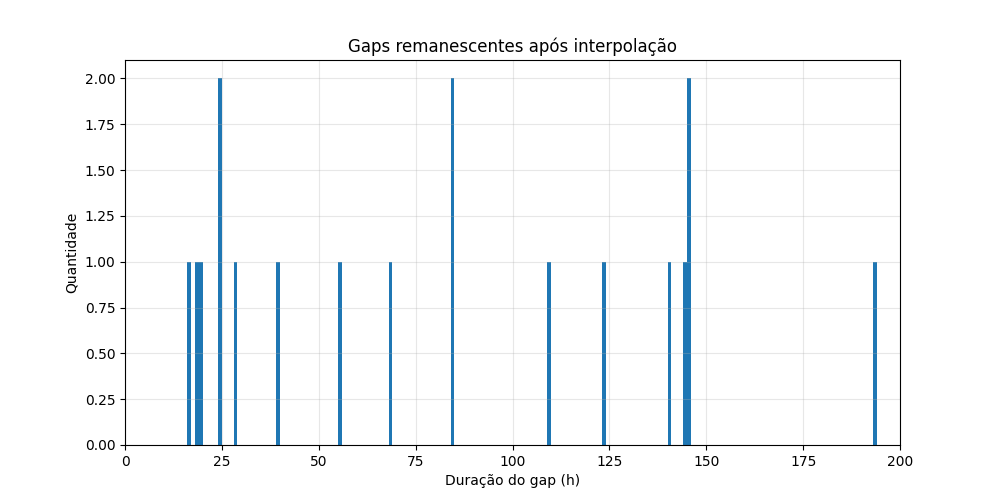

In [30]:
fig, ax = plt.subplots(figsize=(10,5))

ax.hist(
    gaps_interp["duracao_h"],
    bins=np.arange(1, 200, 1)
)

ax.set_xlabel("Duração do gap (h)")
ax.set_ylabel("Quantidade")
ax.set_xlim([0,200])
ax.set_title("Gaps remanescentes após interpolação")
ax.grid(alpha=0.3)

plt.show()

In [31]:
completude_original = (
    df.loc["2016-03-01":, "MP2.5"]
    .notna()
    .mean()
    * 100
)

completude_interp = (
    df_estrategia02["MP2.5"]
    .notna()
    .mean()
    * 100
)

print(f"Original     : {completude_original:.2f}%")
print(f"Interpolado  : {completude_interp:.2f}%")
print(f"Ganho        : {completude_interp - completude_original:.2f}%")

Original     : 94.90%
Interpolado  : 95.20%
Ganho        : 0.30%


In [ ]:
#salvar
df_estrategia02.to_csv(
   "../data/data_interpolacao_gaps_menores/dados_full_features_2016_2019_interp12h.csv",
   index=True
)

### Estratégia 3 - PM25_imputado = média do mesmo mês + mesma hora + mesmo dia da semana

In [33]:
df_estrategia03 = df.loc["2016-03-01":].copy()
df_estrategia03.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [34]:
# somente interpolar para janelas de até 12h.
is_nan = df_estrategia03['MP2.5'].isna()
grupos = (is_nan != is_nan.shift()).cumsum()

In [35]:
serie_interp = df_estrategia03['MP2.5'].copy()

for _, grupo in df_estrategia03['MP2.5'].groupby(grupos):

    if grupo.isna().all():

        tamanho_gap = len(grupo)

        # só interpola se o gap inteiro tiver até 12h
        if tamanho_gap <= limite_gap:

            inicio = grupo.index[0]
            fim = grupo.index[-1]

            serie_interp.loc[inicio:fim] = (
                df_estrategia03['MP2.5']
                .interpolate(method="time", limit_area="inside")
                .loc[inicio:fim]
            )

df_estrategia03['MP2.5'] = serie_interp

In [36]:
# #interpolação temporal até 12 h
# df_estrategia03["MP2.5"] = (
#     df_estrategia03["MP2.5"]
#     .interpolate(
#         method="time",
#         limit=12,
#         limit_area="inside"
#     )
# )

In [37]:
# cria variáveis temporais
df_estrategia03["mes"] = df_estrategia03.index.month
df_estrategia03["hora"] = df_estrategia03.index.hour
df_estrategia03["dia_semana"] = df_estrategia03.index.dayofweek

# flag: o que ainda está NaN depois da interpolação <=12h
df_estrategia03["MP2.5_imputado_media"] = df_estrategia03["MP2.5"].isna().astype(int)


In [38]:
# média do mesmo mês + dia da semana + hora
media_mdh = (
    df_estrategia03
    .groupby(["mes", "dia_semana", "hora"])["MP2.5"]
    .transform("mean")
)
media_mdh

time
2016-03-01 00:00:00+00:00    16.470588
2016-03-01 01:00:00+00:00    19.764706
2016-03-01 02:00:00+00:00    24.176471
2016-03-01 03:00:00+00:00    20.411765
2016-03-01 04:00:00+00:00    17.176471
                               ...    
2019-08-17 22:00:00+00:00    25.785714
2019-08-17 23:00:00+00:00    28.357143
2019-08-18 00:00:00+00:00    29.785714
2019-08-18 01:00:00+00:00    31.000000
2019-08-18 02:00:00+00:00    33.142857
Name: MP2.5, Length: 30363, dtype: float64

In [39]:
# preenche gaps maiores com essa média
df_estrategia03["MP2.5"] = df_estrategia03["MP2.5"].fillna(media_mdh)

In [40]:
df_original = df.loc["2016-03-01":].copy()

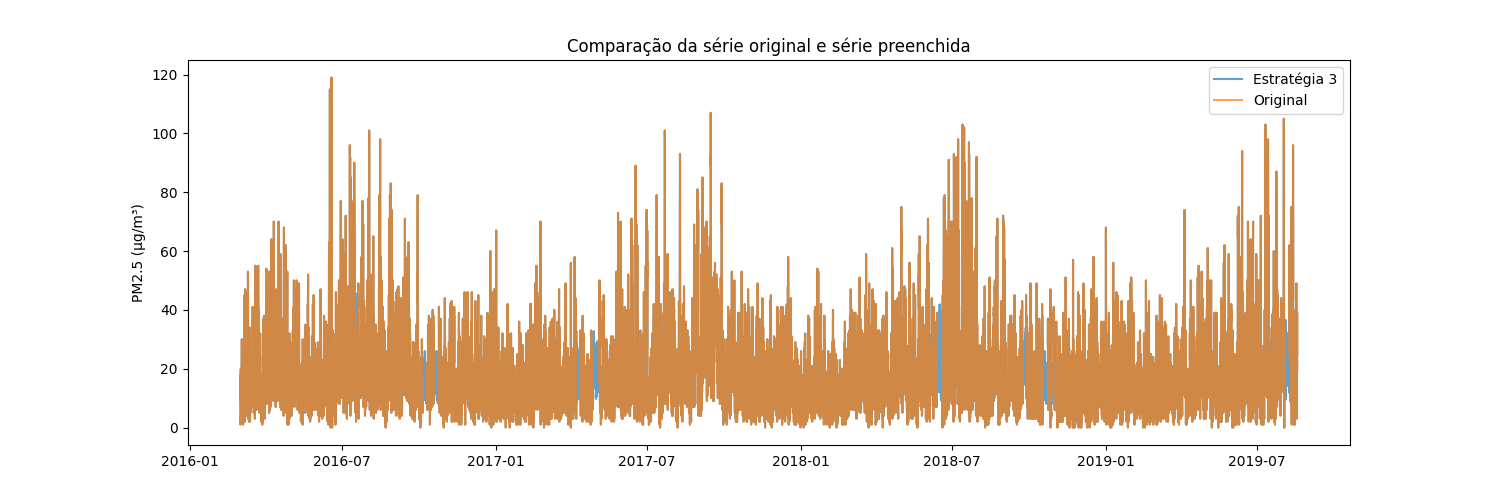

In [41]:
fig, ax = plt.subplots(figsize=(15,5))

ax.plot(
    df_estrategia03.index,
    df_estrategia03["MP2.5"],
    label="Estratégia 3",
    alpha=0.7
)

ax.plot(
    df_original.index,
    df_original["MP2.5"],
    label="Original",
    alpha=0.7
)

ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Comparação da série original e série preenchida")
ax.legend()

plt.show()

In [ ]:
df_estrategia03.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,mes,hora,dia_semana,MP2.5_imputado_media
time,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,3,0,1,0
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,3,1,1,0
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,3,2,1,0
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,3,3,1,0
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,3,4,1,0


In [47]:
df_estrategia03 = df_estrategia03.drop(columns=["mes","hora","dia_semana","MP2.5_imputado_media"])
df_estrategia03.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [48]:
#salvar
df_estrategia03.to_csv(
   "../data/data_interpolacao_gaps_maiores_medias/dados_full_features_2016_2019_fill_mean.csv",
   index=True
)